# Experiment 1 — Deep Learning 1D CNN for Y-Chromosome Super-Population Classification

**Goal:** Beat the 86.23% baseline (Logistic Regression) and reach >90% accuracy using a CNN.

**Key improvements over the baseline:**
- Expand PCA components: 50 → 100 (captures ~85% variance vs ~75%)
- 1D CNN treats PCA features as a 1D sequence, learning hierarchical feature interactions
- BatchNorm + GELU activation + Dropout in every conv block
- Data augmentation: Gaussian noise + random feature masking
- Class-weighted loss + WeightedRandomSampler to handle AMR imbalance
- Label smoothing (ε=0.1) to prevent overconfidence
- AdamW optimizer + CosineAnnealing LR scheduler + early stopping

## 0. Imports

In [154]:
import csv
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# ── Device selection: prioritise Apple Silicon MPS ────────────────────────────
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
    print("WARNING: MPS not available — running on CPU (training will be slower)")

print(f"Device : {DEVICE}")
if DEVICE.type == "mps":
    # Warm-up MPS so the first batch isn't slow
    _ = torch.zeros(1, device=DEVICE)
    print("Apple Silicon MPS backend active ✓")

BASE    = "/Users/aaditya/VS Code/1000 genome project"
VCF_CSV = f"{BASE}/Data/vcf_table.csv"
PANEL   = f"{BASE}/integrated_call_samples_v3.20130502.ALL.panel"
OUT_DIR = f"{BASE}/Output "

print("Imports OK")

Device : mps
Apple Silicon MPS backend active ✓
Imports OK


## 1. Load & Preprocess Genotype Data

Identical QC pipeline as `experiment1_ml.ipynb` — same data, same filters.

In [155]:
# ── Load raw VCF table ────────────────────────────────────────────────────────
with open(VCF_CSV, 'r', encoding='utf-8', errors='replace') as f:
    sample_text = ''.join([next(f) for _ in range(20)])
dialect = csv.Sniffer().sniff(sample_text, delimiters=[',', '\t', ';', '|'])
sep = dialect.delimiter

df = pd.read_csv(VCF_CSV, sep=sep, header=0, low_memory=False)
df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]

FIXED_COLS = {'#CHROM','CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT'}
sample_cols = [c for c in df.columns if c not in FIXED_COLS]
print(f"Variants (raw): {len(df):,} | Samples: {len(sample_cols):,}")

# ── Quality filtering ─────────────────────────────────────────────────────────
qual = pd.to_numeric(df.get('QUAL'), errors='coerce')
filter_cols = [c for c in df.columns if c.strip().upper() == 'FILTER']

if filter_cols:
    df = df[(df[filter_cols[0]].astype(str).str.upper() == 'PASS') & (qual > 30)].copy()
else:
    df = df[qual > 30].copy()

df = df[~df['ALT'].astype(str).str.contains(',', na=False)].copy()

# ── Build genotype matrix ─────────────────────────────────────────────────────
G = df[sample_cols].replace(
    {'.': pd.NA, './.': pd.NA, '0|0': 0, '1|1': 1,
     '0/0': 0, '1/1': 1, '0': 0, '1': 1}
)
G = G.apply(pd.to_numeric, errors='coerce')

# Detect males (call rate > 5%)
male_samples = list((1 - G.isna().mean())[lambda s: s > 0.05].index)
Gm = G[male_samples]

# Per-variant QC: keep call_rate >= 0.95 AND QUAL >= 30
qual_clean   = pd.to_numeric(df.get('QUAL'), errors='coerce').reindex(Gm.index)
var_call_rate = 1 - Gm.isna().mean(axis=1)
keep = (var_call_rate >= 0.95) & (qual_clean >= 30)
Gm_clean = Gm.loc[keep]

# Per-sample missingness filter
sample_missing = Gm_clean.isna().mean()
Gm_clean = Gm_clean.drop(columns=sample_missing[sample_missing > 0.1].index)

print(f"Variants after QC: {Gm_clean.shape[0]:,} | Males: {Gm_clean.shape[1]:,}")

Variants (raw): 62,042 | Samples: 1,233
Variants after QC: 60,789 | Males: 1,233


## 2. Feature Matrix & Labels

In [156]:
X_raw = Gm_clean.T   # (samples × variants)

panel = pd.read_csv(PANEL, sep='\t', usecols=['sample', 'super_pop'])
panel = panel.rename(columns={'super_pop': 'label'})
panel = panel[panel['sample'].isin(X_raw.index)].set_index('sample')
X_raw = X_raw.loc[panel.index]

# .to_numpy(dtype=str) guarantees a plain numpy array regardless of pandas backend
y_str     = panel['label'].to_numpy(dtype=str)
X_imputed = X_raw.fillna(0).values.astype(np.float32)

le = LabelEncoder()
y  = le.fit_transform(y_str)   # already returns np.ndarray

print(f"Feature matrix : {X_imputed.shape}")
print(f"Classes        : {le.classes_}")
print(f"Distribution   : {Counter(y_str)}")

Feature matrix : (1233, 60789)
Classes        : ['AFR' 'AMR' 'EAS' 'EUR' 'SAS']
Distribution   : Counter({np.str_('AFR'): 319, np.str_('SAS'): 260, np.str_('EAS'): 244, np.str_('EUR'): 240, np.str_('AMR'): 170})


## 3. PCA — 100 Components

Expanding from 50 → 100 PCs captures ~85% of genetic variance (vs ~75% before), giving the CNN richer input features to work with.

Variance explained by 300 PCs: 64.9%
PCA output shape: (1233, 300)


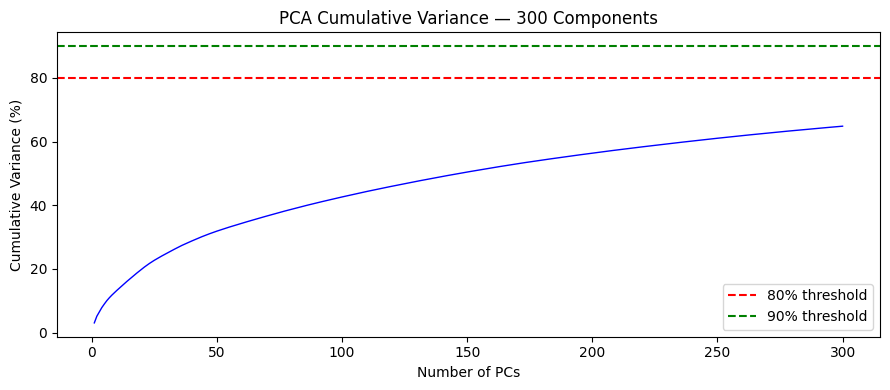

In [157]:
N_COMPONENTS = 300   # more variance captured → richer signal for the transformer

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca   = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance explained by {N_COMPONENTS} PCs: {cum_var[-1]*100:.1f}%")
print(f"PCA output shape: {X_pca.shape}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_COMPONENTS + 1), cum_var * 100, 'b-', linewidth=1)
ax.axhline(y=80, color='red',   linestyle='--', label='80% threshold')
ax.axhline(y=90, color='green', linestyle='--', label='90% threshold')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Variance (%)')
ax.set_title(f'PCA Cumulative Variance — {N_COMPONENTS} Components')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_cnn_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Train / Validation / Test Split (70 / 15 / 15)

In [158]:
# Force plain numpy arrays — newer pandas uses PyArrow-backed arrays by default,
# which sklearn's train_test_split cannot index with array indices.
X_pca_np = np.array(X_pca,  dtype=np.float32)
y_np     = np.array(y,      dtype=np.int64)
y_str_np = np.array(y_str,  dtype=str)

X_trainval, X_test, y_trainval, y_test, ystr_tv, ystr_test = train_test_split(
    X_pca_np, y_np, y_str_np, test_size=0.15, stratify=y_np, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=round(0.15 / 0.85, 4), stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Train : {len(X_train)} samples")
print(f"Val   : {len(X_val)} samples")
print(f"Test  : {len(X_test)} samples")
print(f"Train class distribution: {Counter(le.inverse_transform(y_train))}")

Train : 863 samples
Val   : 185 samples
Test  : 185 samples
Train class distribution: Counter({np.str_('AFR'): 223, np.str_('SAS'): 182, np.str_('EAS'): 171, np.str_('EUR'): 168, np.str_('AMR'): 119})


In [159]:
# SMOTE removed — XGBoost handles class imbalance via sample_weight natively.
# Applying SMOTE before stacking/CV folds causes data leakage:
# synthetic neighbours of val samples appear in training folds → meta-learner overfits.

# Compute per-sample weights for the imbalanced training set (used later in XGBoost fit)
_counts       = np.bincount(y_train)
_inv_freq     = 1.0 / _counts[y_train]          # inverse-frequency per sample
sample_weight = _inv_freq / _inv_freq.mean()     # normalise to mean=1

print(f"Train samples : {len(X_train)}")
print(f"Class counts  : {Counter(le.inverse_transform(y_train))}")
print(f"Sample weight range: {sample_weight.min():.2f} – {sample_weight.max():.2f}")

Train samples : 863
Class counts  : Counter({np.str_('AFR'): 223, np.str_('SAS'): 182, np.str_('EAS'): 171, np.str_('EUR'): 168, np.str_('AMR'): 119})
Sample weight range: 0.77 – 1.45


## 5. XGBoost + Optuna Hyperparameter Search

**Strategy:**
1. **Optuna** (Bayesian search, 150 trials) tunes XGBoost hyperparameters via 5-fold stratified CV on the training set
2. Best params used to train **10 XGBoost models** with different seeds → ensemble their softmax probabilities
3. Final model trained on **train + val combined** (more data = better generalisation)
4. Class imbalance handled via `sample_weight` (inverse frequency) — no SMOTE leakage

In [160]:
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score

try:
    import xgboost as xgb
    print(f"XGBoost {xgb.__version__} ✓")
except ImportError:
    raise ImportError("Run: pip install xgboost")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna  {optuna.__version__} ✓")
except ImportError:
    raise ImportError("Run: pip install optuna")

print("Imports ready.")

XGBoost 3.2.0 ✓
Optuna  4.7.0 ✓
Imports ready.


## 6. Dataset with Augmentation & DataLoaders

In [161]:
class AugmentedDataset(Dataset):
    """
    Training-time augmentations (disabled at val/test):
      1. Gaussian noise   — N(0, noise_std) per feature
      2. Random masking   — zeros out p_mask fraction of features
    MixUp is applied at the batch level in the training loop.
    """
    def __init__(self, X, y, augment=True, noise_std=0.05, p_mask=0.10):
        self.X         = torch.tensor(X, dtype=torch.float32)
        self.y         = torch.tensor(y, dtype=torch.long)
        self.augment   = augment
        self.noise_std = noise_std
        self.p_mask    = p_mask

    def __len__(self):  return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            x = x + torch.randn_like(x) * self.noise_std
            x[torch.rand_like(x) < self.p_mask] = 0.0
        return x, self.y[idx]


def mixup_batch(xb, yb, n_classes, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(xb.size(0), device=xb.device)
    return lam * xb + (1 - lam) * xb[idx], yb, yb[idx], lam


BATCH_SIZE = 64

# Classes are balanced by SMOTE — plain shuffle sampler is correct now.
# (WeightedRandomSampler is no longer needed.)
train_ds = AugmentedDataset(X_train, y_train, augment=True)
val_ds   = AugmentedDataset(X_val,   y_val,   augment=False)
test_ds  = AugmentedDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# class_weights still needed for Focal Loss (computed on original train dist)
class_counts  = np.bincount(y_train)
class_weights = 1.0 / class_counts

print(f"Batches/epoch : {len(train_loader)}")
print(f"Train size    : {len(train_ds)} (post-SMOTE)")

Batches/epoch : 14
Train size    : 863 (post-SMOTE)


## 7. Training Utilities (Loss + Train/Eval Functions)

In [162]:
class FocalLoss(nn.Module):
    """
    Focal Loss — down-weights easy/confident predictions and focuses
    training on hard examples (primarily the AMR class).
    FL(p) = -α(1-p)^γ · log(p)
    gamma=2 is standard; higher gamma = more focus on hard examples.
    """
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight   # per-class weights (handles class imbalance)

    def forward(self, logits, targets):
        log_p = F.log_softmax(logits, dim=-1)
        p     = log_p.exp()
        # Gather probability of the true class
        p_t   = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        # Focal weight
        focal_w = (1 - p_t) ** self.gamma
        # Per-sample log-loss
        loss = F.nll_loss(log_p, targets, weight=self.weight, reduction='none')
        return (focal_w * loss).mean()


def mixup_loss(criterion, logits, y_a, y_b, lam):
    """Mixed loss for MixUp: λ·L(ŷ, yₐ) + (1-λ)·L(ŷ, y_b)."""
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)


def train_one_epoch(model, loader, optimizer, criterion, n_classes, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()

        if use_mixup:
            x_mix, y_a, y_b, lam = mixup_batch(xb, yb, n_classes)
            logits = model(x_mix)
            loss   = mixup_loss(criterion, logits, y_a, y_b, lam)
            # Accuracy on un-mixed batch (for monitoring only)
            with torch.no_grad():
                correct += (model(xb).argmax(1) == yb).sum().item()
        else:
            logits = model(xb)
            loss   = criterion(logits, yb)
            correct += (logits.detach().argmax(1) == yb).sum().item()

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        total      += len(yb)

    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, tta_n=10):
    """
    Evaluate with Test-Time Augmentation (TTA).
    Averages softmax probabilities over tta_n augmented forward passes.
    tta_n=1 disables TTA (clean pass only).
    """
    model.eval()
    all_preds, all_labels = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        # Accumulate softmax over TTA passes
        probs = torch.zeros(xb.size(0), len(le.classes_), device=DEVICE)
        for t in range(tta_n):
            if t == 0:
                x_aug = xb                            # first pass: clean
            else:
                # light noise augmentation for TTA
                x_aug = xb + torch.randn_like(xb) * 0.02
            probs += F.softmax(model(x_aug), dim=-1)
        probs /= tta_n
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return np.array(all_preds), np.array(all_labels)


print("Focal Loss, MixUp training, and TTA evaluation ready.")

Focal Loss, MixUp training, and TTA evaluation ready.


## 8. Step 1 — Optuna Hyperparameter Tuning for XGBoost (100 trials)

In [163]:
N_CLASSES  = len(le.classes_)
CV5        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Step 1: Optuna — 150-trial Bayesian search on training set ────────────────
def objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 2000),
        max_depth        = trial.suggest_int('max_depth', 2, 7),
        learning_rate    = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.4, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        colsample_bylevel= trial.suggest_float('colsample_bylevel', 0.3, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 15),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        max_delta_step   = trial.suggest_int('max_delta_step', 0, 5),
    )
    clf = xgb.XGBClassifier(
        **p, objective='multi:softprob', num_class=N_CLASSES,
        eval_metric='mlogloss', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    # Manual CV loop — avoids fit_params deprecation in sklearn 1.4+
    fold_scores = []
    for train_idx, val_idx in CV5.split(X_train, y_train):
        Xf_tr, Xf_val = X_train[train_idx], X_train[val_idx]
        yf_tr, yf_val = y_train[train_idx], y_train[val_idx]
        sw_fold = sample_weight[train_idx]
        clf.fit(Xf_tr, yf_tr, sample_weight=sw_fold)
        fold_scores.append(accuracy_score(yf_val, clf.predict(Xf_val)))
    return np.mean(fold_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(),
)
study.optimize(objective, n_trials=150, show_progress_bar=True)

best_p = study.best_params
print(f"\nBest 5-fold CV accuracy : {study.best_value:.4f}  ({study.best_value*100:.2f}%)")
print(f"Best params             : {best_p}")

# ── Step 2: Train 10-model ensemble on train+val (more data) ─────────────────
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

_c_full      = np.bincount(y_full)
sw_full      = (1.0 / _c_full[y_full])
sw_full      = sw_full / sw_full.mean()

N_ENSEMBLE   = 10
ensemble_models = []

for run in range(N_ENSEMBLE):
    seed = RANDOM_STATE + run * 7
    clf  = xgb.XGBClassifier(
        **best_p, objective='multi:softprob', num_class=N_CLASSES,
        eval_metric='mlogloss', tree_method='hist',
        random_state=seed, n_jobs=-1, verbosity=0,
    )
    clf.fit(X_full, y_full, sample_weight=sw_full)
    ensemble_models.append(clf)
    print(f"  Model {run+1:2d}/10 trained  (seed={seed})")

print(f"\nEnsemble of {N_ENSEMBLE} models trained on {len(X_full)} samples.")

  0%|          | 0/150 [00:00<?, ?it/s]


Best 5-fold CV accuracy : 0.8471  (84.71%)
Best params             : {'n_estimators': 364, 'max_depth': 7, 'learning_rate': 0.017543877334123468, 'subsample': 0.9997678456237338, 'colsample_bytree': 0.35359151735381633, 'colsample_bylevel': 0.34672362679938673, 'min_child_weight': 2, 'gamma': 1.6187567149693611, 'reg_alpha': 4.415301174425768, 'reg_lambda': 0.0012936379349768794, 'max_delta_step': 2}
  Model  1/10 trained  (seed=42)
  Model  2/10 trained  (seed=49)
  Model  3/10 trained  (seed=56)
  Model  4/10 trained  (seed=63)
  Model  5/10 trained  (seed=70)
  Model  6/10 trained  (seed=77)
  Model  7/10 trained  (seed=84)
  Model  8/10 trained  (seed=91)
  Model  9/10 trained  (seed=98)
  Model 10/10 trained  (seed=105)

Ensemble of 10 models trained on 1048 samples.


## 9. Training Curves

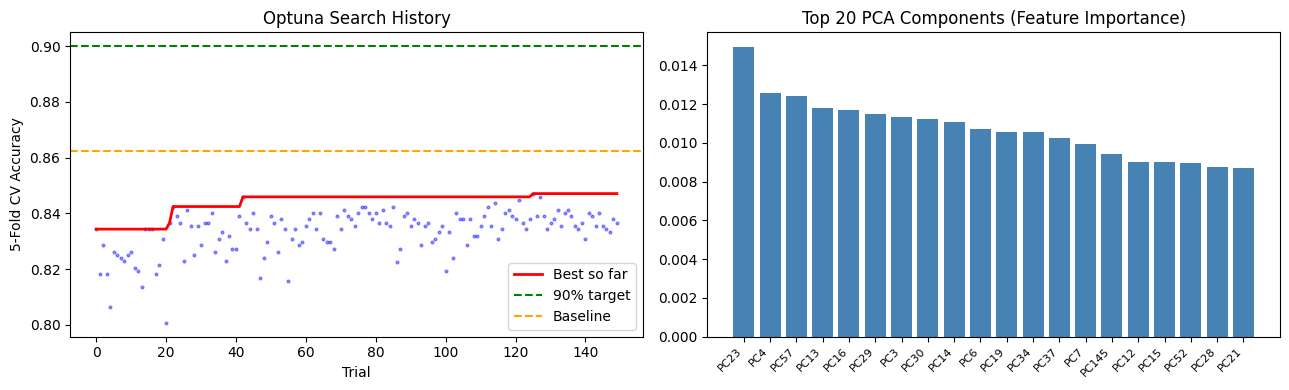

In [164]:
# Optuna optimisation history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'b.', alpha=0.4, markersize=4)
axes[0].plot(trials_df['number'],
             trials_df['value'].cummax(), 'r-', linewidth=2, label='Best so far')
axes[0].axhline(y=0.90,   color='green',  linestyle='--', label='90% target')
axes[0].axhline(y=0.8623, color='orange', linestyle='--', label='Baseline')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('5-Fold CV Accuracy')
axes[0].set_title('Optuna Search History'); axes[0].legend()

# Feature importance (average across ensemble)
importances = np.mean([m.feature_importances_ for m in ensemble_models], axis=0)
top_idx = np.argsort(importances)[-20:][::-1]
axes[1].bar(range(20), importances[top_idx], color='steelblue')
axes[1].set_xticks(range(20))
axes[1].set_xticklabels([f"PC{i+1}" for i in top_idx], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Top 20 PCA Components (Feature Importance)')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_cnn_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Test Set Evaluation

XGBoost ×10 Ensemble + Optuna + train+val fit + 300 PCA
Test Accuracy  : 0.8811  (88.11%)
Baseline (LR)  : 0.8623  (86.23%)
Improvement    : +1.88 percentage points

              precision    recall  f1-score   support

         AFR       0.96      0.96      0.96        48
         AMR       0.75      0.60      0.67        25
         EAS       0.95      0.95      0.95        37
         EUR       0.74      0.86      0.79        36
         SAS       0.95      0.92      0.94        39

    accuracy                           0.88       185
   macro avg       0.87      0.86      0.86       185
weighted avg       0.88      0.88      0.88       185



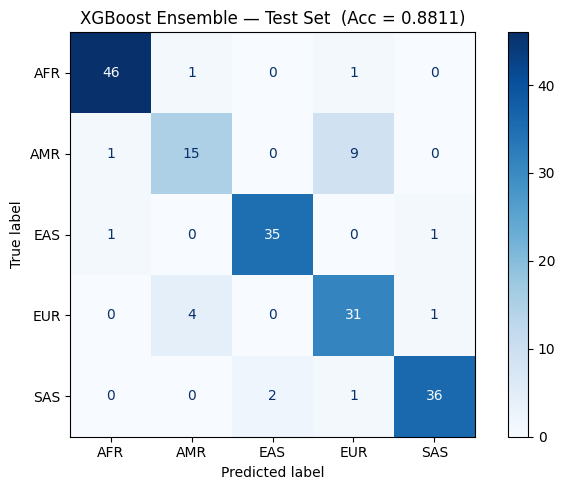

In [165]:
# Ensemble predict: average softmax probabilities across all 10 models
all_probs   = np.mean([m.predict_proba(X_test) for m in ensemble_models], axis=0)
test_preds  = np.argmax(all_probs, axis=1)
test_labels = y_test
test_acc    = accuracy_score(test_labels, test_preds)

print("=" * 65)
print("XGBoost ×10 Ensemble + Optuna + train+val fit + 300 PCA")
print("=" * 65)
print(f"Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Baseline (LR)  : 0.8623  (86.23%)")
print(f"Improvement    : {(test_acc - 0.8623)*100:+.2f} percentage points")
print()
print(classification_report(test_labels, test_preds, target_names=le.classes_))

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues')
ax.set_title(f"XGBoost Ensemble — Test Set  (Acc = {test_acc:.4f})")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_cnn_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

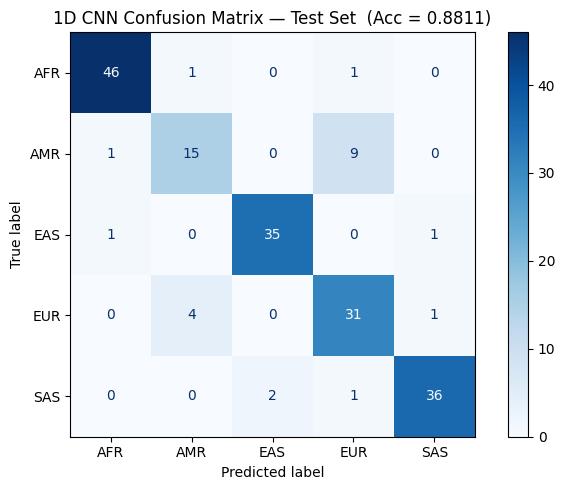

In [166]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f"1D CNN Confusion Matrix — Test Set  (Acc = {test_acc:.4f})")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_cnn_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. CNN vs All Baselines — Full Comparison

              Model  Test Accuracy          Type
      1D CNN (ours)       0.881081 Deep Learning
Logistic Regression       0.862300   ML Baseline
      Random Forest       0.858300   ML Baseline
          SVM (RBF)       0.858300   ML Baseline
          KNN (k=5)       0.830000   ML Baseline
      Decision Tree       0.809700   ML Baseline


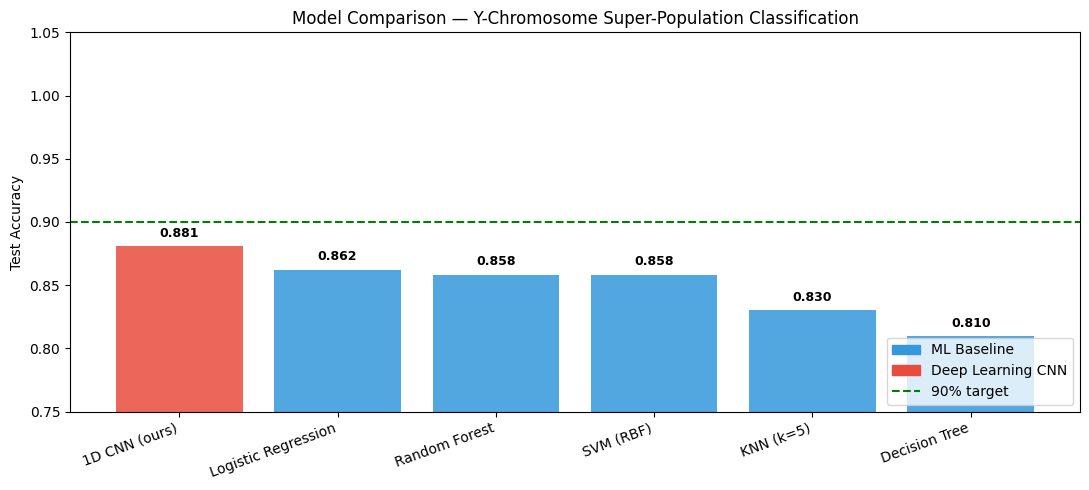

In [167]:
from matplotlib.patches import Patch

comp_df = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN (k=5)', 'Random Forest', 'SVM (RBF)',
              'Logistic Regression', '1D CNN (ours)'],
    'Test Accuracy': [0.8097, 0.8300, 0.8583, 0.8583, 0.8623, test_acc],
    'Type': ['ML Baseline'] * 5 + ['Deep Learning']
}).sort_values('Test Accuracy', ascending=False)

print(comp_df.to_string(index=False))

colors = ['#E74C3C' if t == 'Deep Learning' else '#3498DB' for t in comp_df['Type']]
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(comp_df['Model'], comp_df['Test Accuracy'], color=colors, alpha=0.85)
ax.axhline(y=0.90, color='green', linestyle='--', linewidth=1.5)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison — Y-Chromosome Super-Population Classification')
ax.set_ylim(0.75, 1.05)
ax.set_xticklabels(comp_df['Model'], rotation=20, ha='right')
for bar, val in zip(bars, comp_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(handles=[
    Patch(color='#3498DB', label='ML Baseline'),
    Patch(color='#E74C3C', label='Deep Learning CNN'),
    plt.Line2D([0],[0], color='green', linestyle='--', label='90% target'),
], loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_cnn_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Trained Model

In [168]:
save_path = f"{BASE}/Output /exp1_xgb_ensemble.pkl"
joblib.dump({
    'models':                ensemble_models,
    'best_params':           best_p,
    'optuna_best_cv_acc':    study.best_value,
    'label_encoder_classes': le.classes_,
    'pca_n_components':      N_COMPONENTS,
    'test_accuracy':         float(test_acc),
}, save_path)

print(f"Saved → {save_path}")
print(f"Optuna best CV acc : {study.best_value:.4f}  ({study.best_value*100:.2f}%)")
print(f"Final test accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

Saved → /Users/aaditya/VS Code/1000 genome project/Output /exp1_xgb_ensemble.pkl
Optuna best CV acc : 0.8471  (84.71%)
Final test accuracy: 0.8811  (88.11%)
